## This notebook can be used to rank a list of nodes from a category that connect to an entity such as a gene. 

In [1]:
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import TCT


### Load Translator resources


In [2]:
from TCT.translator_resources import TranslatorResources
resources = TranslatorResources.load()

Skipping server without x-maturity: {'url': '/sipr'}


## Find the neighborhood of an entity from a subset of APIs 


In [3]:
# select a list of APIs to use and a list of predicates to use
selected_APIlist = []

filtered = resources.filter(api_list=selected_APIlist) if selected_APIlist else resources
print(filtered.api_names)
print(filtered.meta_kg.shape)

{'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'Shepherd-arax(Trapi v1.5.0)': 'https://shepherd.ci.transltr.io/arax/query/', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'Genetics Data Provider for NCATS Biomedical Translator Reasoners': 'https://genetics-kp.transltr.io/genetics_provider/trapi/v1.5/query/', 'Automat-drug-central(Trapi v1.5.0)': 'https://automat.renci.org/drugcentral/query/', 'Automat-icees-kg(Trapi v1.5.0)': 'https://automat.transltr.io/icees-kg/query/', 'Automat-cam-kp(Trapi v1.5.0)': 'https://automat.transltr.io/cam-kp/query/', 'Multiomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/multiomics/query', 'ARAX Translator Reasoner - TRAPI 1.6.0': 'https://arax.transltr.io/api/arax/v1.4/query/', 'COHD TRAPI': 'https://cohd-api.transltr

In order to use the neighborhood finder, we have to look up a CURIE ID for a given term.

In [4]:
name_resolver.lookup(query='BCL2')
name_resolver.lookup(query='ABCB1', return_top_response=False, biolink_type='biolink:Gene', limit=100, only_taxa='NCBITaxon:9606')  # sometimes the identifiers are not in the top 1, users need to check the other returned results

[TranslatorNode(curie='NCBIGene:5243', label='ABCB1', types=['biolink:Gene', 'biolink:GeneOrGeneProduct', 'biolink:GenomicEntity', 'biolink:ChemicalEntityOrGeneOrGeneProduct', 'biolink:PhysicalEssence', 'biolink:OntologyClass', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity', 'biolink:PhysicalEssenceOrOccurrent', 'biolink:MacromolecularMachineMixin', 'biolink:Protein', 'biolink:GeneProductMixin', 'biolink:Polypeptide', 'biolink:ChemicalEntityOrProteinOrPolypeptide'], synonyms=None, curie_synonyms=None, attributes=None, taxa=['NCBITaxon:9606'])]

nb_result = TCT.Neiborhood_finder(input_node='NCBIGene:596',
                                   node2_categories=['biolink:Gene', 'biolink:Protein'],
                                   resources=filtered)
input_node_id = nb_result.input_node_id
result = nb_result.knowledge_graph
result_parsed = nb_result.parsed
result_ranked_by_primary_infores = nb_result.ranked

In [5]:
nb_result = TCT.Neiborhood_finder(input_node='NCBIGene:596',
                                   node2_categories=['biolink:Gene', 'biolink:Protein'],
                                   resources=filtered)
input_node_id = nb_result.input_node_id
result = nb_result.knowledge_graph
result_parsed = nb_result.parsed
result_ranked_by_primary_infores = nb_result.ranked

NCBIGene:596
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
RTX KG2 - TRAPI 1.5.0: Success!
Automat-genome-alliance(Trapi v1.5.0): Success!
Automat-cam-kp(Trapi v1.5.0): Success!
BioThings Explorer (BTE) TRAPI: Success!
Automat-robokop(Trapi v1.5.0): Success!
Automat-hetionet(Trapi v1.5.0): Success!
NodeNorm does not know about these identifiers: orphanet:119007


In [6]:
result

NodeNorm does not know about these identifiers: orphanet:119007


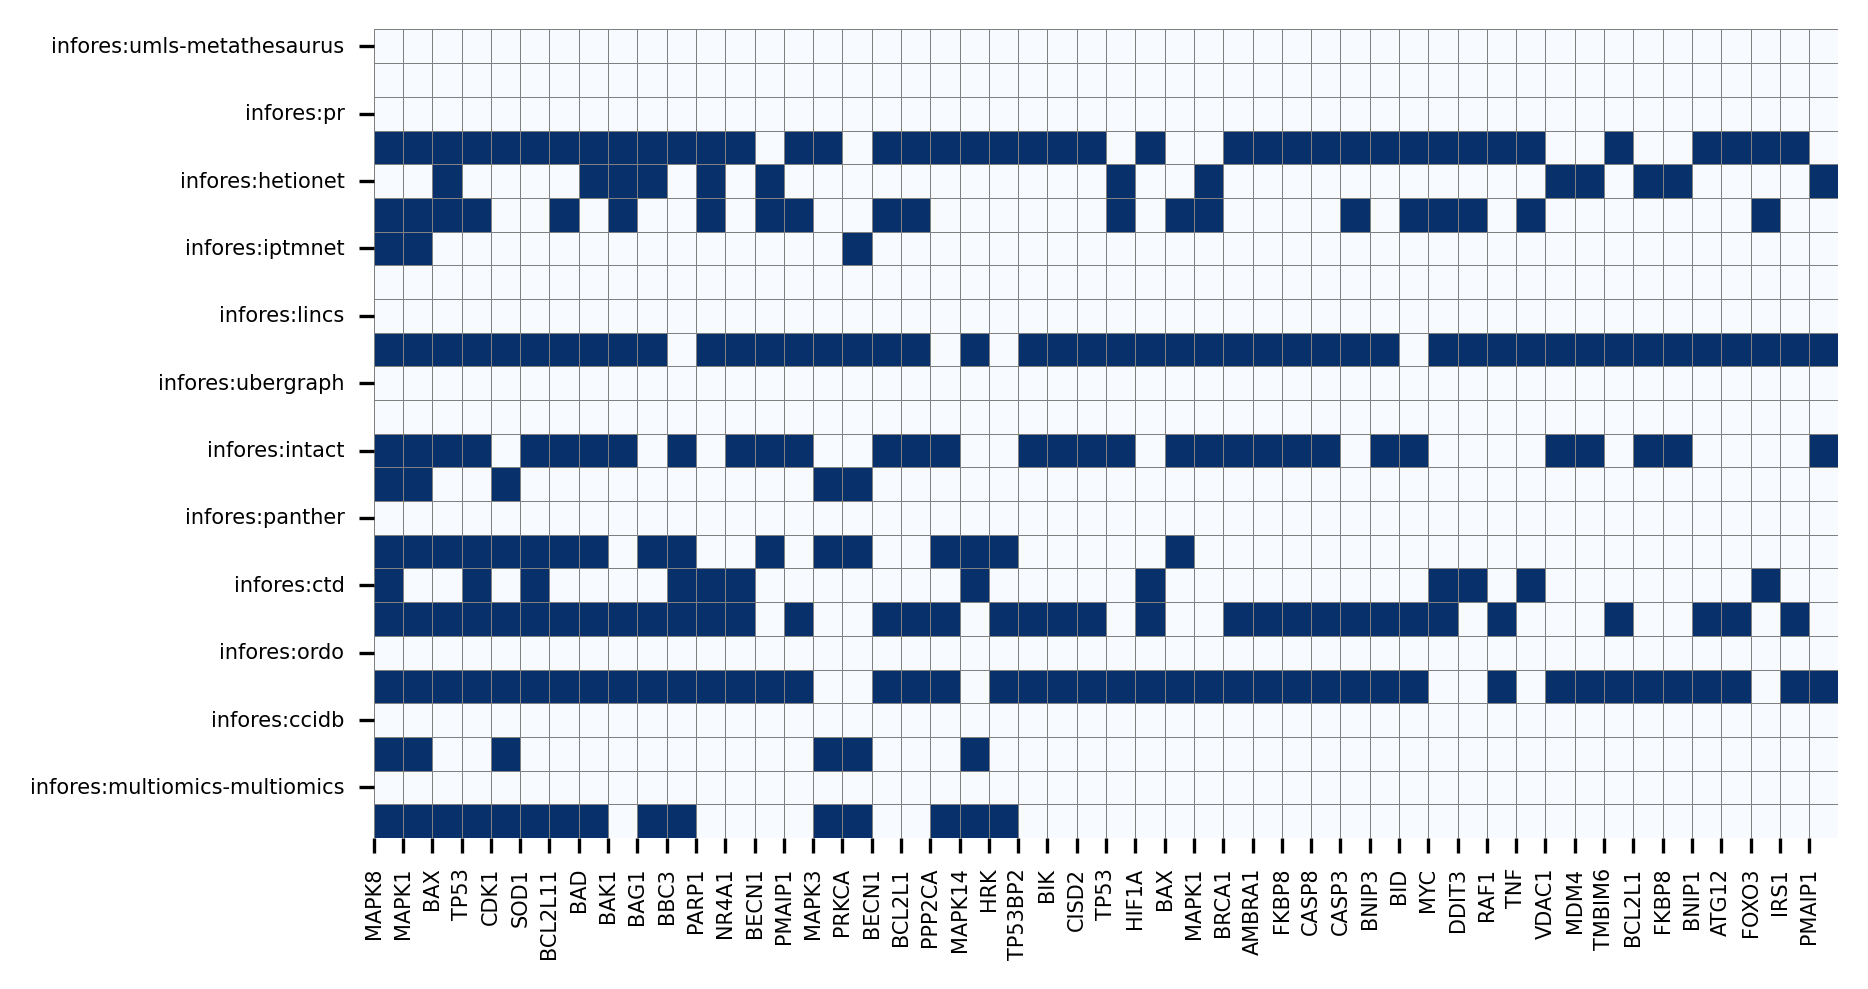

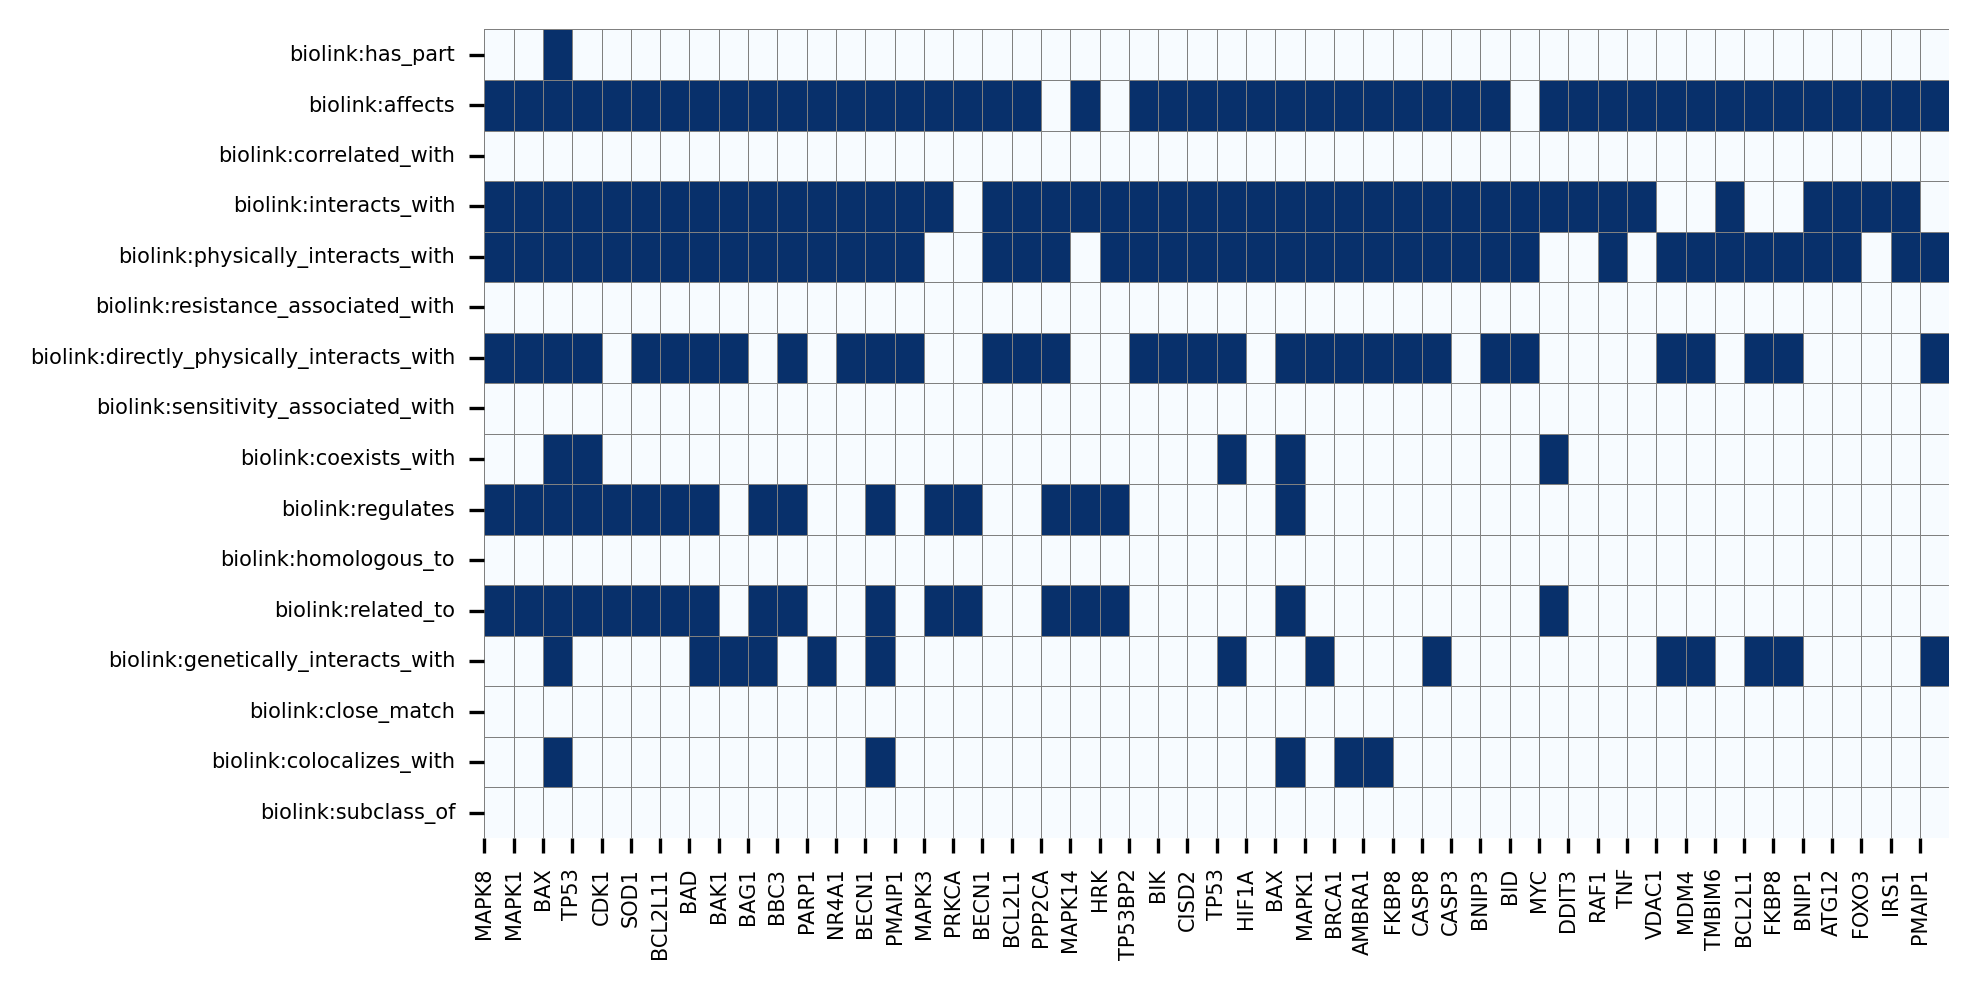

,MAPK8,MAPK1,BAX,TP53,CDK1,SOD1,BCL2L11,BAD,BAK1,BAG1,...,HOXA10,HOXA9,HOXA9,HOXA3,HOXA1,HNF4A,APAF1,HMOX1,HMGA1,BAX_RAT Apoptosis regulator BAX (sprot)
biolink:has_part,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:affects,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
biolink:correlated_with,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:interacts_with,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:physically_interacts_with,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:resistance_associated_with,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:directly_physically_interacts_with,1,1,1,1,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,1
biolink:sensitivity_associated_with,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:coexists_with,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:regulates,1,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Step 8: Visualize the results
TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores=result_ranked_by_primary_infores,
                                result_parsed=result_parsed,
                                num_of_nodes=50,
                                input_query=input_node_id,
                                fontsize=5)

In [8]:
result_ranked_by_primary_infores

,output_node,Name,Num_of_primary_infores,type_of_nodes,unique_predicates
10,NCBIGene:5599,MAPK8,12,subject,"[biolink:regulates, biolink:physically_interac..."
8,NCBIGene:5594,MAPK1,11,subject,"[biolink:regulates, biolink:physically_interac..."
24,NCBIGene:581,BAX,9,subject,"[biolink:regulates, biolink:physically_interac..."
23,NCBIGene:7157,TP53,9,subject,"[biolink:regulates, biolink:physically_interac..."
30,NCBIGene:983,CDK1,8,subject,"[biolink:regulates, biolink:physically_interac..."
...,...,...,...,...,...
1053,NCBIGene:3172,HNF4A,1,subject,[biolink:affects]
1052,NCBIGene:317,APAF1,1,object,"[biolink:affects, biolink:affects]"
1051,NCBIGene:3162,HMOX1,1,object,[biolink:affects]
1050,NCBIGene:3159,HMGA1,1,object,[biolink:affects]


In [9]:
from TCT import visualization

dic_graph = visualization.visualize_neighborhood_graph(result=result, show_label=True, height="500", width="100%")

NodeNorm does not know about these identifiers: orphanet:119007
regulates.html
physically_interacts_with.html
genetically_interacts_with.html
affects.html
teracts_with.html
coexists_with.html
related_t.html
has_part.html
subclass_of.html
directly_physically_interacts_with.html
colocalizes_with.html
close_match.html
sensitivity_associated_with.html
resistance_associated_with.html
homologous_t.html
correlated_with.html


In [10]:
import networkx as nx
from pyvis.network import Network
#G1 = dic_graph['treats']
G2 = dic_graph['directly_physically_interacts_with']
#G3 = dic_graph['_clinical_trials_for']
G_merged = nx.compose_all([G2])
# remove self-loops
G_merged.remove_edges_from(nx.selfloop_edges(G_merged))
# remove duplicate edges
G_merged = nx.Graph(G_merged)
# Select nodes with degree > 10
selected_nodes = ['BCL2']
# select the first neighbors of the selected nodes
for node in list(selected_nodes):
    neighbors = list(G_merged.neighbors(node))
    selected_nodes.extend(neighbors) # expand the selected nodes by adding their neighbors and only keep top 50 nodes
selected_nodes = list(set(selected_nodes))[:100] # keep only top 50 nodes
subgraph = G_merged.subgraph(selected_nodes).copy()

net = Network(height="1000px", width="100%", notebook=True, cdn_resources="in_line")
net.from_nx(subgraph)

# Remove edge labels before passing to PyVis
for u, v, d in subgraph.edges(data=True):
    d.pop("label", None)  # remove 'label' if it exists


for e in net.edges:
    e["title"] = "\n".join([f"{k}: {v}" for k,v in subgraph[e["from"]][e["to"]].items()])
# add title in the figure
title_html = f"<h3>merged_graph</h3>"
net.title = title_html + f"<p>Nodes: {net.num_nodes()} Edges: {net.num_edges()}</p>"
net.show("merged_graph.html")

merged_graph.html


In [11]:
# put G2 into table format
import pandas as pd
edges_data = []
for u, v, d in G2.edges(data=True):
    edge_info = {
        'source': u,
        'target': v,
    }
    edge_info.update(d)  # add all edge attributes
    edges_data.append(edge_info)

edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('BCL2_directly_physically_interacts_with_edges.csv', index=False)

In [12]:
# End of the example
